In [ ]:
#
# Universidad EAFIT 
# 2025-1
#

In [ ]:
# cargar las librerias necesarias
## 1. nltk para 'procesamiento natural del lenguaje'
## 2. pandas para procesamiento de dataframes, muy usado en preparación de datos
## 3. re - expresiones regulares
## 4. numpy, codecs, etc - otraas

In [26]:
!pip3 install nltk pandas matplotlib scikit-learn -q

In [27]:
import nltk
import pandas as pd
import numpy as np
import re
import codecs
import matplotlib.pyplot as plt
import os

In [8]:
ls

Lecture01.pdf    README.md        class01-1.ipynb  class01-2.ipynb


In [11]:
print(os.getcwd())

/Users/andrestrepo/Documents/repos_personal/si7003nlp_eafit/Lecture01


In [14]:
os.chdir('..')


In [17]:
!ls 'datasets/gutenberg-es/'

48903-0.txt 58221-0.txt pg45438.txt pg47631.txt
57654-0.txt pg2000.txt  pg47287.txt pg62627.txt


In [18]:
# directorios (path) de entrada y salida:
# 
path_in="datasets/gutenberg-es/"
path_out="out/"
filenametxt='pg2000.txt'
filenamecleantxt='pg2000_clean.txt'
filenamecsv='pg2000.csv'

In [19]:
# corpus de nltk para 'tokenizer' y 'stopwords'
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/andrestrepo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/andrestrepo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andrestrepo/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to
[nltk_data]     /Users/andrestrepo/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/andrestrepo/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/andrestrepo/nltk_data...


True

In [ ]:
# las demás instrucciones del lab1-nltk-local.ipynb

In [20]:
# ejemplo de como nltk tokeniza:
texto="texto libre que permite crear     hiso20091iras epor--4 no s#e preocupe \n hola mundo cruel"
tokens = nltk.word_tokenize(texto)
print(len(tokens))
print(tokens)

17
['texto', 'libre', 'que', 'permite', 'crear', 'hiso20091iras', 'epor', '--', '4', 'no', 's', '#', 'e', 'preocupe', 'hola', 'mundo', 'cruel']


In [21]:
# note la estrategia de tokenizar con sentencias simples de python, 
# ¿ cual le parece mejor?
# y note la diferencia entre .split() y .split(' ')
texto="texto libre que permite crear     hiso20091iras            epor--4 no s#e preocupe \n hola mundo cruel"
tokens = texto.split()
print(len(tokens))
print(tokens)
tokens = texto.split(' ')
print(len(tokens))
print(tokens)

13
['texto', 'libre', 'que', 'permite', 'crear', 'hiso20091iras', 'epor--4', 'no', 's#e', 'preocupe', 'hola', 'mundo', 'cruel']
29
['texto', 'libre', 'que', 'permite', 'crear', '', '', '', '', 'hiso20091iras', '', '', '', '', '', '', '', '', '', '', '', 'epor--4', 'no', 's#e', 'preocupe', '\n', 'hola', 'mundo', 'cruel']


In [22]:
# stopwords en nltk
from nltk.corpus import stopwords
 
stop_words_nltk = set(stopwords.words('spanish'))
stop_words_nltk_en = set(stopwords.words('english'))
print(len(stop_words_nltk_en))
print(stop_words_nltk_en)

179
{'over', "mightn't", 'weren', "doesn't", 'won', 'between', "that'll", "aren't", 'those', "mustn't", 'she', 'was', 'does', 'because', 'hers', 'while', "hasn't", 'mightn', 'him', 'am', 'into', 'few', 'wasn', 'where', "didn't", "won't", 'themselves', 'been', 'hadn', 'further', 'ourselves', "wouldn't", 'be', 's', 'had', 'you', 'what', "hadn't", 'that', 'her', 'at', 'now', 'most', 'being', 'do', 'up', "wasn't", "shouldn't", 'his', 'theirs', "couldn't", 'shan', 'some', 'couldn', 'a', "should've", 'not', 'my', 'for', 'ain', 'and', 'through', "you're", 'below', 'same', 'o', 'as', 'than', 'me', 'to', 'mustn', 'it', 'our', 'or', 'when', 'any', 'myself', 'too', 'he', "you've", 'doesn', 'once', 'an', 'all', 'y', "isn't", 'only', 'but', 'yourself', 'more', 'ours', 'shouldn', 'has', 'don', 'in', "don't", 'its', 'before', 'these', "you'd", 'aren', "it's", 'about', 've', "she's", 'no', 'will', 'on', 'they', 'own', 'needn', 'herself', 'there', 'yourselves', 'other', 'nor', 'haven', 'from', 're', 'i

In [23]:
# permite verificar en nltk si un token pertenece a diccionario de un idioma, en este caso a 'english'
from nltk.corpus import words as voc_en

x = len(voc_en.words())
print('tamaño del diccionario en inglés del nltk: ',x)

# verifica si una palabra pertenece al diccionario:
w = "house"
if (len(w) >1) and w.isalpha() and (w in voc_en.words()) and (w not in stop_words_nltk_en):
    print(w," true")
else:
    print(w," false")
    
w = "pepito"
if (len(w) >1) and w.isalpha() and (w in voc_en.words()) and (w not in stop_words_nltk_en):
    print(w," true")
else:
    print(w," false")    

tamaño del diccionario en inglés del nltk:  236736
house  true
pepito  false


In [24]:
# leer un archivo de ejemplo en .txt
input_file = open(path_in+filenametxt, "r", encoding='iso-8859-1')
filedata = input_file.read()

In [28]:
# Tokenización de n-grams usando Scikit-learn

from sklearn.feature_extraction.text import CountVectorizer

# Texto de ejemplo
text = ["El gato está durmiendo tranquilamente en el sofá"]

# Crear un CountVectorizer con diferentes valores de n
vectorizer = CountVectorizer(ngram_range=(1, 3))  # Unigramas, bigramas y trigramas
X = vectorizer.fit_transform(text)

# Mostrar los n-grams generados
print("N-grams generados:", vectorizer.get_feature_names_out())
print("Matriz de conteo:\n", X.toarray())

N-grams generados: ['durmiendo' 'durmiendo tranquilamente' 'durmiendo tranquilamente en' 'el'
 'el gato' 'el gato está' 'el sofá' 'en' 'en el' 'en el sofá' 'está'
 'está durmiendo' 'está durmiendo tranquilamente' 'gato' 'gato está'
 'gato está durmiendo' 'sofá' 'tranquilamente' 'tranquilamente en'
 'tranquilamente en el']
Matriz de conteo:
 [[1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [29]:
# Tokenización de n-grams manual
def generate_ngrams(text, n):
    """
    Genera una lista de n-grams a partir de un texto.
    """
    tokens = text.split()  # Tokenización básica por espacios
    ngrams = [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return ngrams

# Texto de ejemplo
text = "El gato está durmiendo tranquilamente en el sofá"

# Generar n-grams para diferentes valores de n
for n in range(1, 4):  # Unigramas, bigramas, trigramas
    print(f"{n}-grams:", generate_ngrams(text, n))

1-grams: ['El', 'gato', 'está', 'durmiendo', 'tranquilamente', 'en', 'el', 'sofá']
2-grams: ['El gato', 'gato está', 'está durmiendo', 'durmiendo tranquilamente', 'tranquilamente en', 'en el', 'el sofá']
3-grams: ['El gato está', 'gato está durmiendo', 'está durmiendo tranquilamente', 'durmiendo tranquilamente en', 'tranquilamente en el', 'en el sofá']


numero de palabras finales =  22840
[('don', 2652), ('quijote', 2180), ('sancho', 2148), ('ms', 2044), ('si', 1966), ('dijo', 1808), ('ser', 1293), ('tan', 1243), ('as', 1075), ('seor', 1063), ('respondi', 1063), ('bien', 1050), ('haba', 1034), ('merced', 900), ('pues', 865), ('qu', 849), ('sino', 694), ('dos', 684), ('caballero', 661), ('decir', 578)]


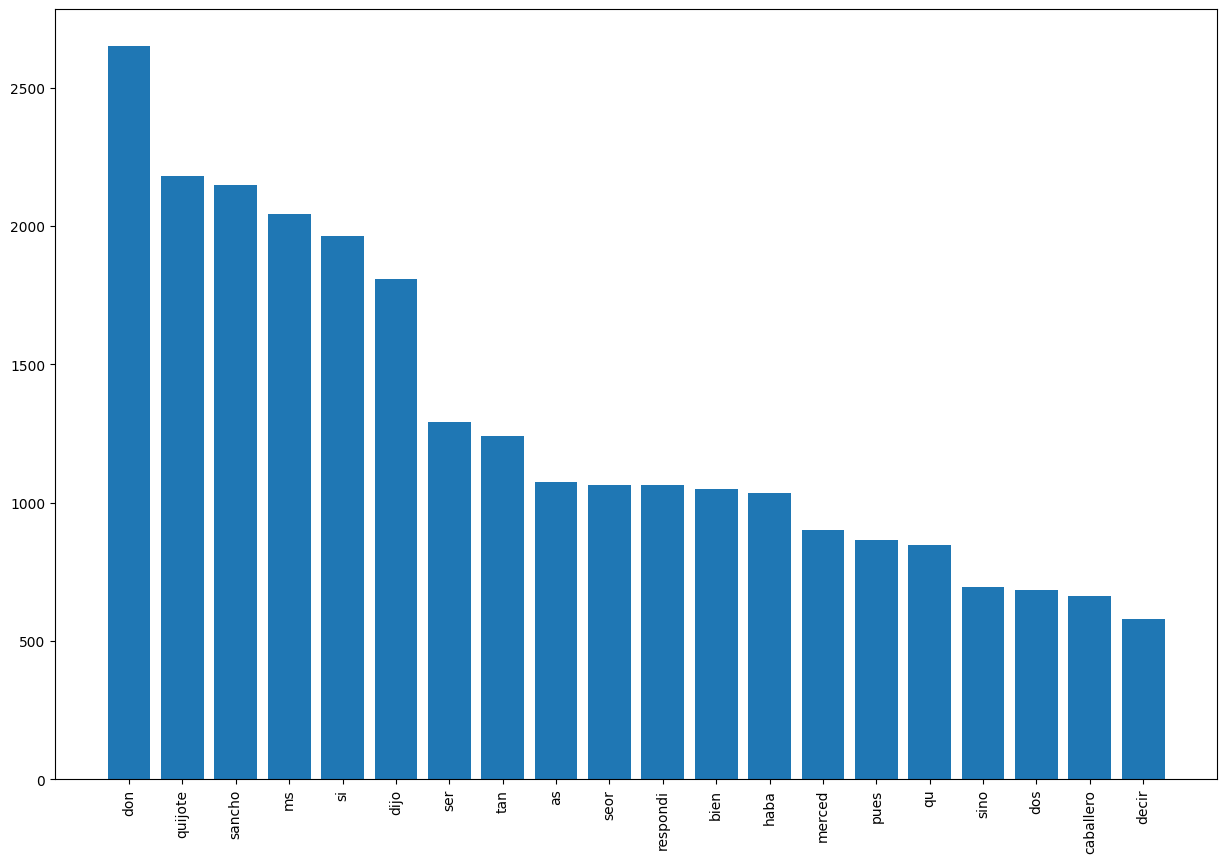

In [30]:
# opción 1:
# TOKENIZAR con .split(), 
# ELIMINAR tokens de long = 1
# ELIMINAR caracteres que no sean alfanumericos y pasar todo a minuscula
# REMOVER stop words con nltk
# graficar los 20 términos más frecuentes:

tokens = filedata.split()
tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
# tokens=[word for word in tokens if word.isalpha()] si en vez de re.sub(r'[^A-Za-z0-9]+','',w) hace esto, que pasa?
tokens = [w.lower() for w in tokens if len(w)>1]
tokens = [w for w in tokens if w not in stop_words_nltk]

fdist = nltk.FreqDist(tokens)
print('numero de palabras finales = ',len(fdist))
topwords = fdist.most_common(20)
print (topwords)
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  22836
[('don', 2652), ('quijote', 2180), ('sancho', 2148), ('ms', 2044), ('si', 1966), ('dijo', 1808), ('ser', 1293), ('l', 1283), ('tan', 1243), ('as', 1075), ('seor', 1063), ('respondi', 1063), ('bien', 1050), ('haba', 1034), ('merced', 900), ('pues', 865), ('qu', 849), ('s', 742), ('sino', 694), ('dos', 684)]


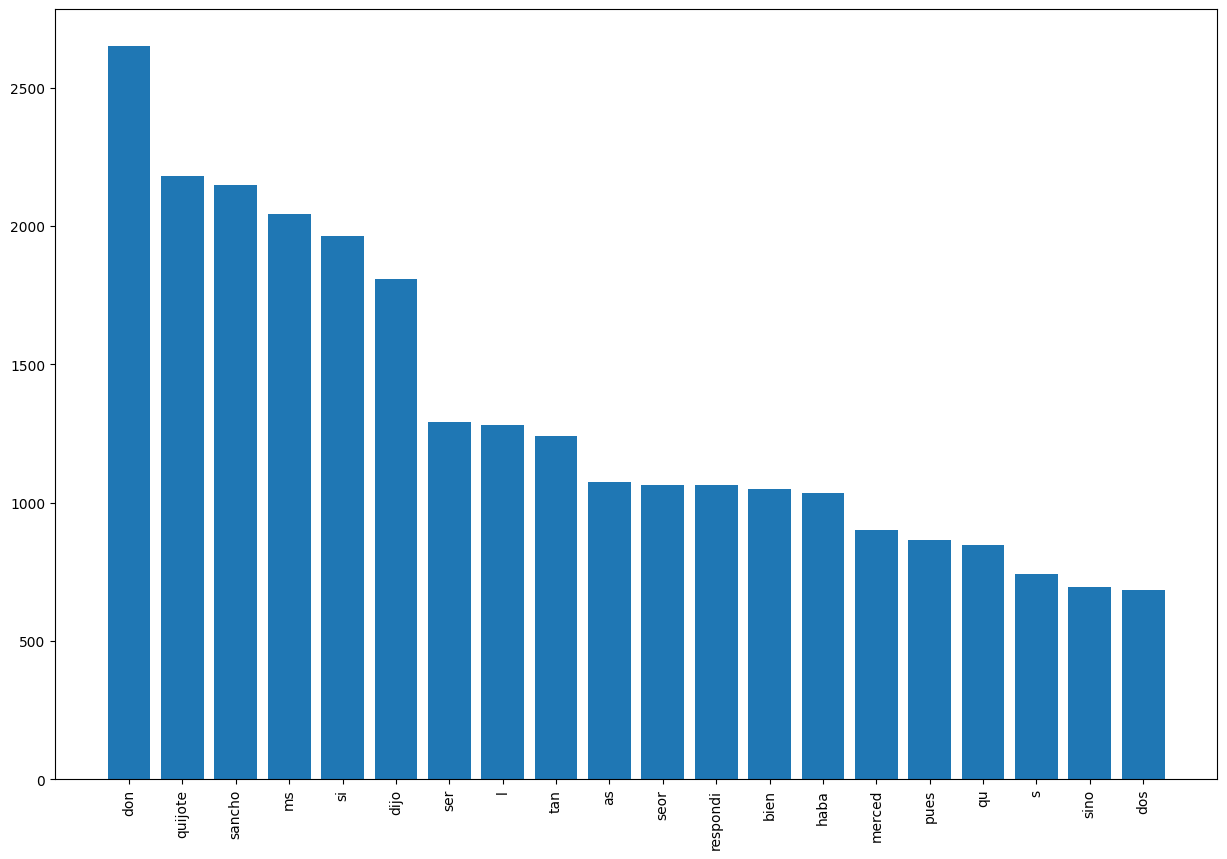

In [31]:
# opción 2:
# TOKENIZAR con nltk, 
# ELIMINAR tokens de long = 1
# ELIMINAR caracteres que no sean alfanumericos
# REMOVER stop words
# graficar los 20 términos más frecuentes:

tokens = nltk.word_tokenize(filedata)
tokens = [w.lower() for w in tokens if len(w)>1]
tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
tokens = [w for w in tokens if w not in stop_words_nltk]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
print (topwords)
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  17400


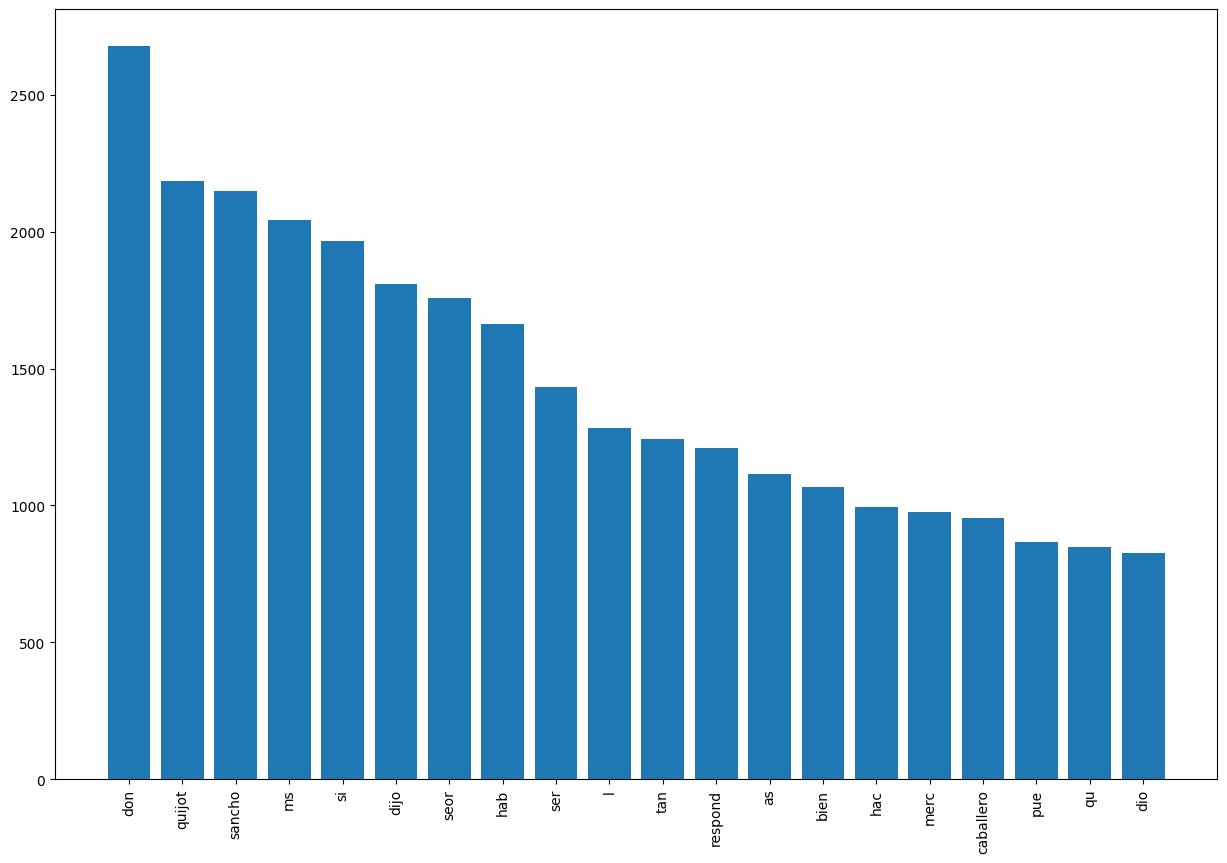

In [32]:
# Stemming con NLTK

from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer

porter = PorterStemmer()
lancaster = LancasterStemmer()
# probar cada una de las siguientes opciones: porter y lancaster.
#tokens = [porter.stem(w) for w in tokens]
tokens = [lancaster.stem(w) for w in tokens]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

numero de palabras finales =  17333


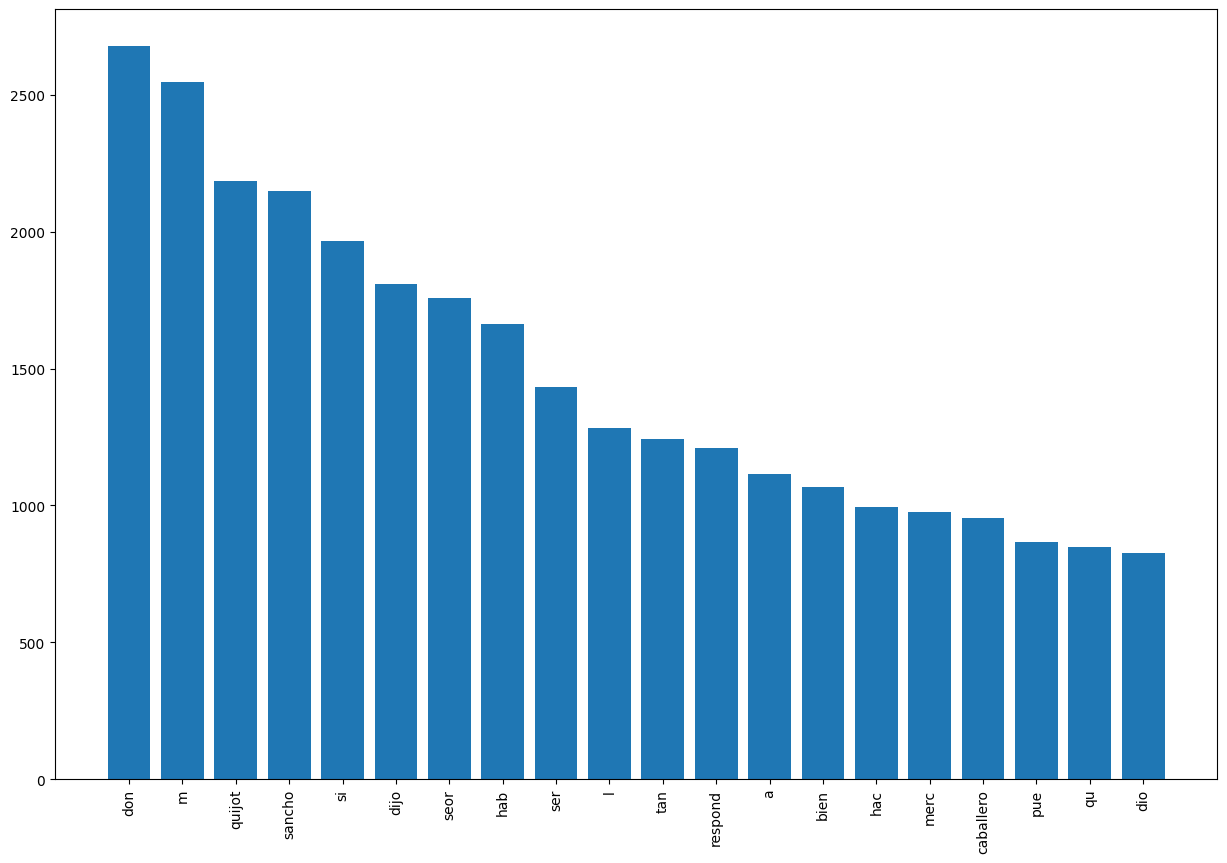

In [33]:
# Lemmatization con NLTK

from nltk.stem import WordNetLemmatizer

wordnet_lemmatizer = WordNetLemmatizer()

# probar cada una de las siguientes opciones: 
#tokens = [wordnet_lemmatizer.lemmatize(w, pos="v") for w in tokens ]
tokens = [wordnet_lemmatizer.lemmatize(w) for w in tokens ]

fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

In [34]:
# volver a leer el archivo ejemplo en .txt
#input_file = open(path_in+filenametxt, "r",encoding='iso-8859-1')
input_file = open(path_in+filenametxt, "r")
output_file_clean = open(path_out+filenamecleantxt, "w")

In [35]:
from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer

porter = PorterStemmer()
lancaster = LancasterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

for line in input_file:
    line_clean = ""
    tokens = nltk.word_tokenize(line)
    tokens = [re.sub(r'[^A-Za-z0-9]+','',w) for w in tokens]
    tokens = [w.lower() for w in tokens if len(w)>1]
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words_nltk]
    #tokens = [wordnet_lemmatizer.lemmatize(w, pos="v") for w in tokens]
    tokens = [wordnet_lemmatizer.lemmatize(w) for w in tokens]

    #tokens = [porter.stem(w) for w in tokens]
    tokens = [lancaster.stem(w) for w in tokens]
    
    for w in tokens:
        line_clean=line_clean+w+" "
            
    if (line_clean!=""):
        line_clean=line_clean+"\n"
        output_file_clean.write(line_clean)
output_file_clean.close()   

In [36]:
input_file_clean = open(path_out+filenamecleantxt, "r", encoding='iso-8859-1')

numero de palabras finales =  17270


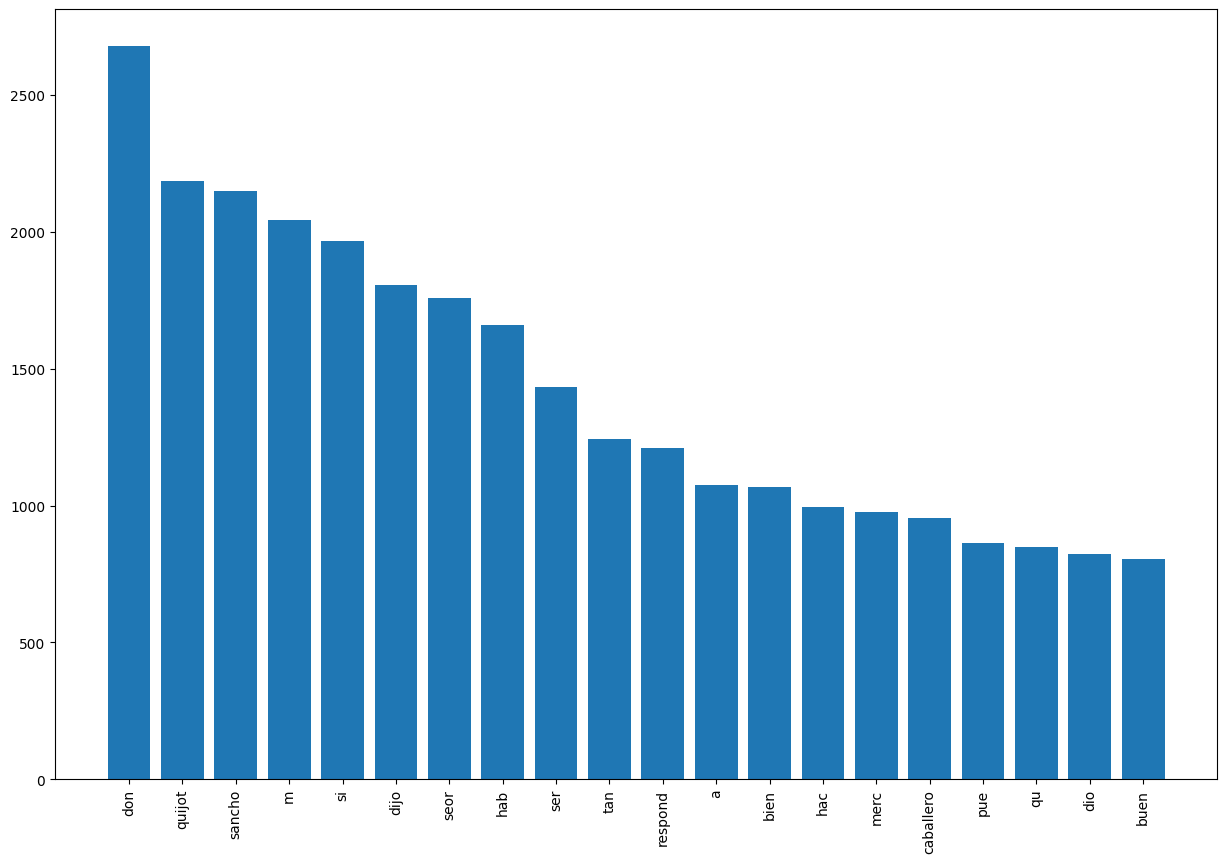

In [37]:
filedata = input_file_clean.read()
tokens = filedata.split()
fdist = nltk.FreqDist(tokens)
topwords = fdist.most_common(20)
print('numero de palabras finales = ',len(fdist))
x,y = zip(*topwords)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

In [38]:
word_freq = fdist.most_common(len(fdist))

In [41]:
import csv

with open(path_out+filenamecsv, 'w') as csvFile:
    writer = csv.writer(csvFile)
    writer.writerow(["word", "frecuency"])
    writer.writerows(word_freq)

csvFile.close()

In [42]:
# extract top 30 words
top_words = word_freq[:20]
print(top_words)

[('don', 2680), ('quijot', 2186), ('sancho', 2150), ('m', 2044), ('si', 1966), ('dijo', 1808), ('seor', 1758), ('hab', 1662), ('ser', 1433), ('tan', 1243), ('respond', 1211), ('a', 1075), ('bien', 1068), ('hac', 994), ('merc', 976), ('caballero', 954), ('pue', 865), ('qu', 849), ('dio', 825), ('buen', 805)]


In [43]:
import pandas as pd
df = pd.DataFrame(top_words)
df.head()

,0,1
0,don,2680
1,quijot,2186
2,sancho,2150
3,m,2044
4,si,1966


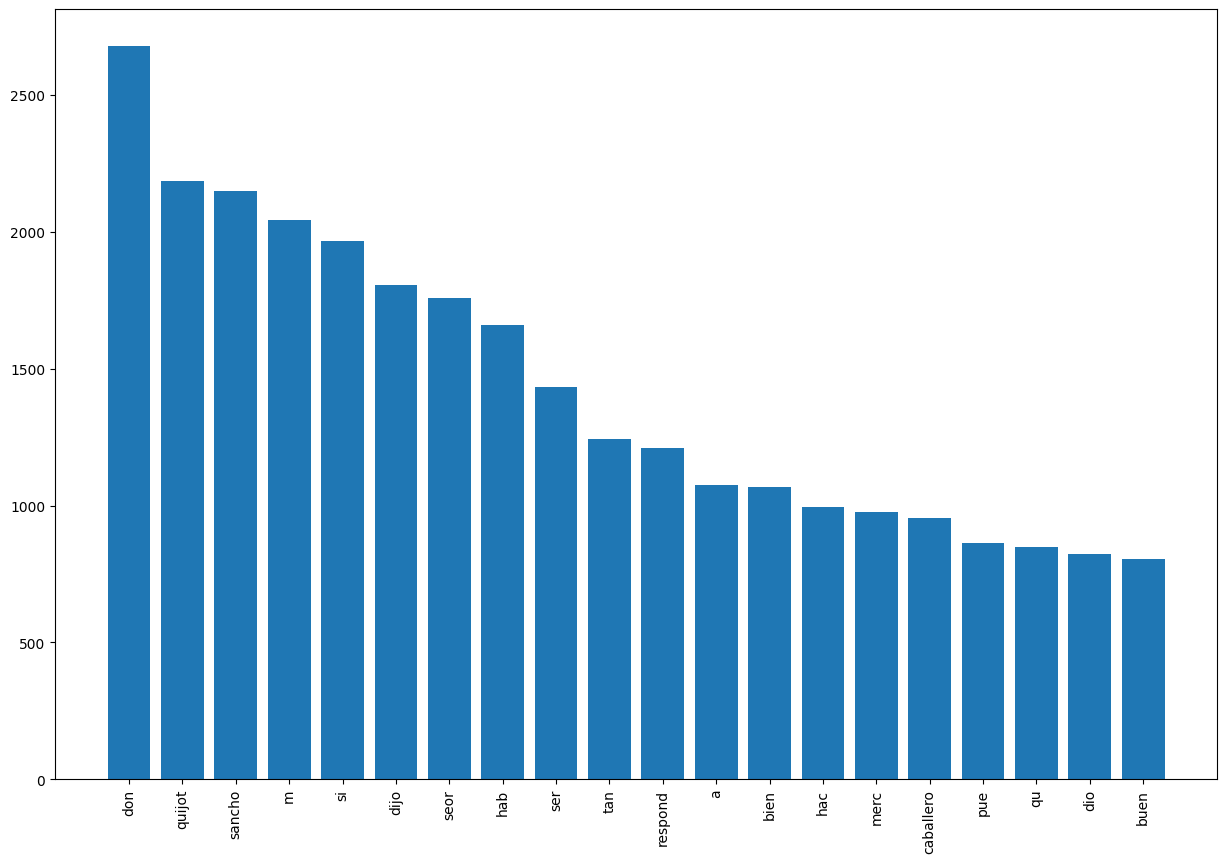

In [44]:
import matplotlib.pyplot as plt
x,y = zip(*top_words)
plt.figure(figsize=(15,10))
plt.bar(x,y)
plt.xticks(rotation=90)
plt.show()

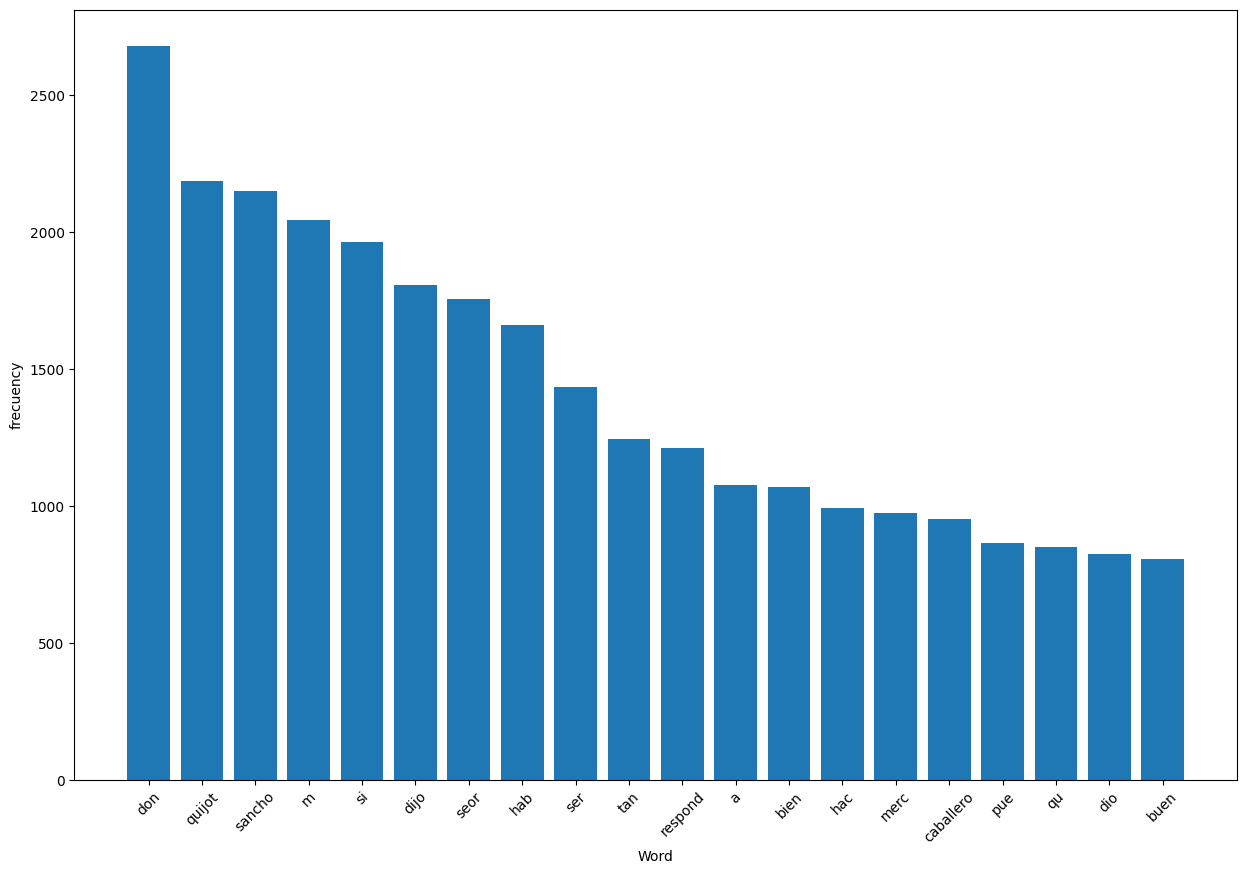

In [45]:
import matplotlib.pyplot as plt
df = pd.DataFrame(top_words)
plt.figure(figsize=(15,10))
plt.bar(df[0],df[1])
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("frecuency")
plt.show()

In [46]:
# Tokenización de n-grams usando Scikit-learn

from sklearn.feature_extraction.text import CountVectorizer

# Texto de ejemplo
text = ["El gato está durmiendo tranquilamente en el sofá"]

# Crear un CountVectorizer con diferentes valores de n
vectorizer = CountVectorizer(ngram_range=(1, 3))  # Unigramas, bigramas y trigramas
X = vectorizer.fit_transform(text)

# Mostrar los n-grams generados
print("N-grams generados:", vectorizer.get_feature_names_out())
print("Matriz de conteo:\n", X.toarray())


N-grams generados: ['durmiendo' 'durmiendo tranquilamente' 'durmiendo tranquilamente en' 'el'
 'el gato' 'el gato está' 'el sofá' 'en' 'en el' 'en el sofá' 'está'
 'está durmiendo' 'está durmiendo tranquilamente' 'gato' 'gato está'
 'gato está durmiendo' 'sofá' 'tranquilamente' 'tranquilamente en'
 'tranquilamente en el']
Matriz de conteo:
 [[1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [47]:
# Tokenización de n-grams implementada manualmente

def generate_ngrams(text, n):
    """
    Genera una lista de n-grams a partir de un texto.
    """
    tokens = text.split()  # Tokenización básica por espacios
    ngrams = [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    return ngrams

# Texto de ejemplo
text = "El gato está durmiendo tranquilamente en el sofá"

# Generar n-grams para diferentes valores de n
for n in range(1, 4):  # Unigramas, bigramas, trigramas
    print(f"{n}-grams:", generate_ngrams(text, n))


1-grams: ['El', 'gato', 'está', 'durmiendo', 'tranquilamente', 'en', 'el', 'sofá']
2-grams: ['El gato', 'gato está', 'está durmiendo', 'durmiendo tranquilamente', 'tranquilamente en', 'en el', 'el sofá']
3-grams: ['El gato está', 'gato está durmiendo', 'está durmiendo tranquilamente', 'durmiendo tranquilamente en', 'tranquilamente en el', 'en el sofá']


In [48]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
texts = [
    "good movie", "not a good movie", "did not like", 
    "i like it", "good one"
]

# Ejemplo de documentos
texts2 = [
    "El gato está durmiendo",
    "El perro está jugando",
    "El gato y el perro son amigos",
    "A los gatos les gusta dormir todo el día"
]

# using default tokenizer in TfidfVectorizer
tfidf = TfidfVectorizer(min_df=1, max_df=0.5, ngram_range=(1, 2))
features = tfidf.fit_transform(texts2)
pd.DataFrame(
    features.todense(),
    columns=tfidf.get_feature_names_out()
)

,amigos,dormir,dormir todo,durmiendo,día,el día,el gato,el perro,está,está durmiendo,...,les gusta,los,los gatos,perro,perro está,perro son,son,son amigos,todo,todo el
0,0.000000,0.000000,0.000000,0.453386,0.000000,0.000000,0.357455,0.000000,0.357455,0.453386,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.357455,0.357455,0.000000,...,0.000000,0.000000,0.000000,0.357455,0.453386,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.365481,0.000000,0.000000,0.000000,0.000000,0.000000,0.288149,0.288149,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.288149,0.000000,0.365481,0.365481,0.365481,0.000000,0.000000
3,0.000000,0.267261,0.267261,0.000000,0.267261,0.267261,0.000000,0.000000,0.000000,0.000000,...,0.267261,0.267261,0.267261,0.000000,0.000000,0.000000,0.000000,0.000000,0.267261,0.267261
